In [1]:
import os, sys, pickle, numpy as np, pandas as pd

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
eigen_steering.WEIGHTS_PATH = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/pytorch_base_model/model_fold_0.safetensors'
eigen_steering.RESULTS_DIR = os.path.join(REPO, 'models')
from eigen_steering import EigenMap

lib_path = os.path.join(REPO, 'virtual_perturbations', 'libraries', 'hippo_target_library.pkl')
with open(lib_path, 'rb') as f:
    lib = pickle.load(f)

df = lib['df']
focus_tfs = lib['focus_tfs']

# Build EigenMap — HepG2 first so it plots on top
CT = {'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
em = EigenMap(model_names=CT, device='cuda')

em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

# Build seq_idx -> raw npz index mapping (npz has all seq_valid rows,
# df used the additional keep filter dropping 3 rows)
raw = np.load(lib['attr_npz_path'])
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna()
n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
raw_indices = np.arange(n)[keep]  # filtered_idx -> raw npz idx
del df_full

ohe = em.X.numpy()
idxs = df.seq_idx.values
npz_idxs = raw_indices[idxs]  # correct mapping
for ct in CT:
    hyp = raw[f'attr_{ct}'][npz_idxs]
    em.attr_hyp[ct] = hyp
    em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][npz_idxs]

em.motif_hits = lib['motif_hits']
em.eigen_results = lib['eigen_results']

print(f'Loaded {len(df)} sequences')
print(f'  Conditions: {df["condition"].value_counts().to_dict()}')
print(f'  Focus TFs: {len(focus_tfs)}')
print(f'  Cell type order: {em.cell_types} (top row first)')

AlphaGenome patches applied (all functional activations -> nn.Module).
EigenMap: ['HepG2', 'K562'], models={'HepG2': 'HepG2_v6_do03', 'K562': 'K562_v6_do075'}
Loaded 1059 sequences, X shape: torch.Size([1059, 4, 281])
Loaded 1059 sequences
  Conditions: {'same-diff': 353, 'diff-diff': 353, 'same-same': 353}
  Focus TFs: 151
  Cell type order: ['HepG2', 'K562'] (top row first)


## Necessity and sufficiency tests across library (local and global effects)

In [2]:
# run necessity and sufficiency tests on all sequences
n_rep = 20
nec_order = 2
suf_order = 2

all_nec = em.necessity_test(seq_idx=None, n_rep=n_rep,
                            nec_order=nec_order, batch_size=516, random_state=42)
all_suf = em.sufficiency_test(seq_idx=None, n_rep=n_rep,
                              suf_order=suf_order, suff_pos=None,
                              batch_size=516, random_state=42)

  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt


  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  necessity: 1059/1059 sequences
  Loading HepG2: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/checkpoints/best_stage2.pt
  Loading K562: /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/checkpoints/best_stage2.pt
  sufficiency: 1059/1059 sequences


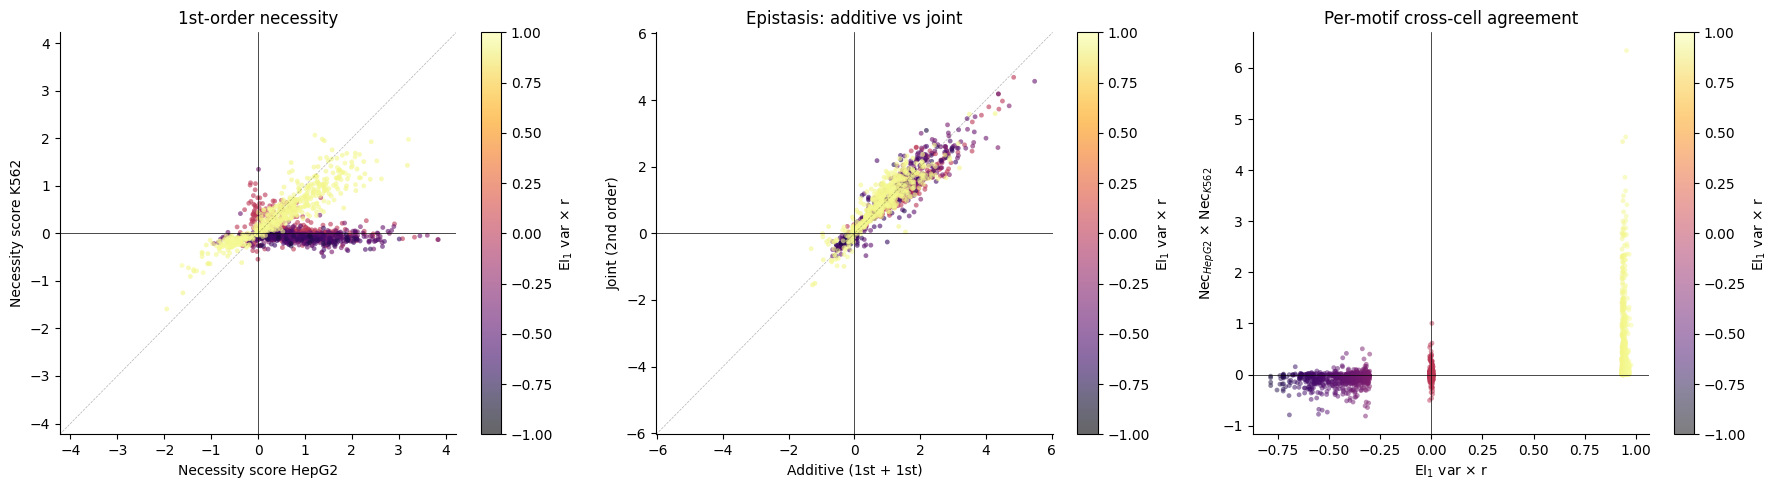

1647 1st-order necessity tests across 1059 sequences


In [27]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# collect 1st-order necessity scores (flip sign: positive = more necessary)
nec_rows = []
for si, tests in enumerate(all_nec):
    for t in tests:
        if t['order'] == 1:
            nec_rows.append({
                'seq_idx': si,
                'tf': t['motifs'][0]['tf'],
                'start': t['motifs'][0]['start'],
                'end': t['motifs'][0]['end'],
                'nec_HepG2': -t['scores']['HepG2'],
                'nec_K562': -t['scores']['K562'],
                'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
            })
nec_df = pd.DataFrame(nec_rows)
# per-motif agreement: positive = both lines agree, negative = divergent
nec_df['agreement'] = nec_df['nec_HepG2'] * nec_df['nec_K562']

# collect 2nd-order necessity scores
nec2_rows = []
for si, tests in enumerate(all_nec):
    for t in tests:
        if t['order'] == 2:
            nec2_rows.append({
                'seq_idx': si,
                'nec2_HepG2': -t['scores']['HepG2'],
                'nec2_K562': -t['scores']['K562'],
            })
nec2_df = pd.DataFrame(nec2_rows) if nec2_rows else None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) HepG2 vs K562 necessity scores colored by EI_1 var x r
order = np.argsort(np.abs(nec_df['EI_1_vxr'].values))
sc = axes[0].scatter(nec_df.nec_HepG2.values[order], nec_df.nec_K562.values[order],
                     s=12, alpha=0.6, c=nec_df['EI_1_vxr'].values[order],
                     cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
lim = np.abs(nec_df[['nec_HepG2','nec_K562']].values).max() * 1.1
axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)
axes[0].axhline(0, c='k', lw=0.5); axes[0].axvline(0, c='k', lw=0.5)
axes[0].plot([-lim, lim], [-lim, lim], 'k--', lw=0.5, alpha=0.3)
axes[0].set_xlabel('Necessity score HepG2'); axes[0].set_ylabel('Necessity score K562')
plt.colorbar(sc, ax=axes[0], label='EI$_1$ var $\\times$ r')
axes[0].set_title('1st-order necessity')

# 2) 1st vs 2nd order: epistasis
if nec2_df is not None and len(nec2_df) > 0:
    epi_rows = []
    for si, tests in enumerate(all_nec):
        first = {t['motifs'][0]['tf']: t for t in tests if t['order'] == 1}
        for t in tests:
            if t['order'] == 2:
                tf1, tf2 = t['motifs'][0]['tf'], t['motifs'][1]['tf']
                if tf1 in first and tf2 in first:
                    for ct in ['HepG2', 'K562']:
                        additive = (-first[tf1]['scores'][ct]) + (-first[tf2]['scores'][ct])
                        joint = -t['scores'][ct]
                        epi_rows.append({'seq_idx': si, 'ct': ct,
                                         'additive': additive, 'joint': joint,
                                         'EI_1_vxr': df.iloc[si]['EI_1 var x r']})
    epi_df = pd.DataFrame(epi_rows)
    order_e = np.argsort(np.abs(epi_df['EI_1_vxr'].values))
    sc2 = axes[1].scatter(epi_df.additive.values[order_e], epi_df.joint.values[order_e],
                          s=12, alpha=0.6, c=epi_df['EI_1_vxr'].values[order_e],
                          cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
    elim = max(np.abs(epi_df[['additive','joint']].values).max() * 1.1, 0.1)
    axes[1].set_xlim(-elim, elim); axes[1].set_ylim(-elim, elim)
    axes[1].plot([-elim, elim], [-elim, elim], 'k--', lw=0.5, alpha=0.3)
    axes[1].axhline(0, c='k', lw=0.5); axes[1].axvline(0, c='k', lw=0.5)
    axes[1].set_xlabel('Additive (1st + 1st)'); axes[1].set_ylabel('Joint (2nd order)')
    plt.colorbar(sc2, ax=axes[1], label='EI$_1$ var $\\times$ r')
    axes[1].set_title('Epistasis: additive vs joint')

# 3) per-motif cross-cell agreement vs EI_1 var x r
order_a = np.argsort(np.abs(nec_df['EI_1_vxr'].values))
sc3 = axes[2].scatter(nec_df['EI_1_vxr'].values[order_a],
                      nec_df['agreement'].values[order_a],
                      s=12, alpha=0.5, c=nec_df['EI_1_vxr'].values[order_a],
                      cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
axes[2].axhline(0, c='k', lw=0.5); axes[2].axvline(0, c='k', lw=0.5)
axes[2].set_xlabel('EI$_1$ var $\\times$ r')
axes[2].set_ylabel('Nec$_{HepG2}$ $\\times$ Nec$_{K562}$')
plt.colorbar(sc3, ax=axes[2], label='EI$_1$ var $\\times$ r')
axes[2].set_title('Per-motif cross-cell agreement')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'{len(nec_df)} 1st-order necessity tests across {nec_df.seq_idx.nunique()} sequences')

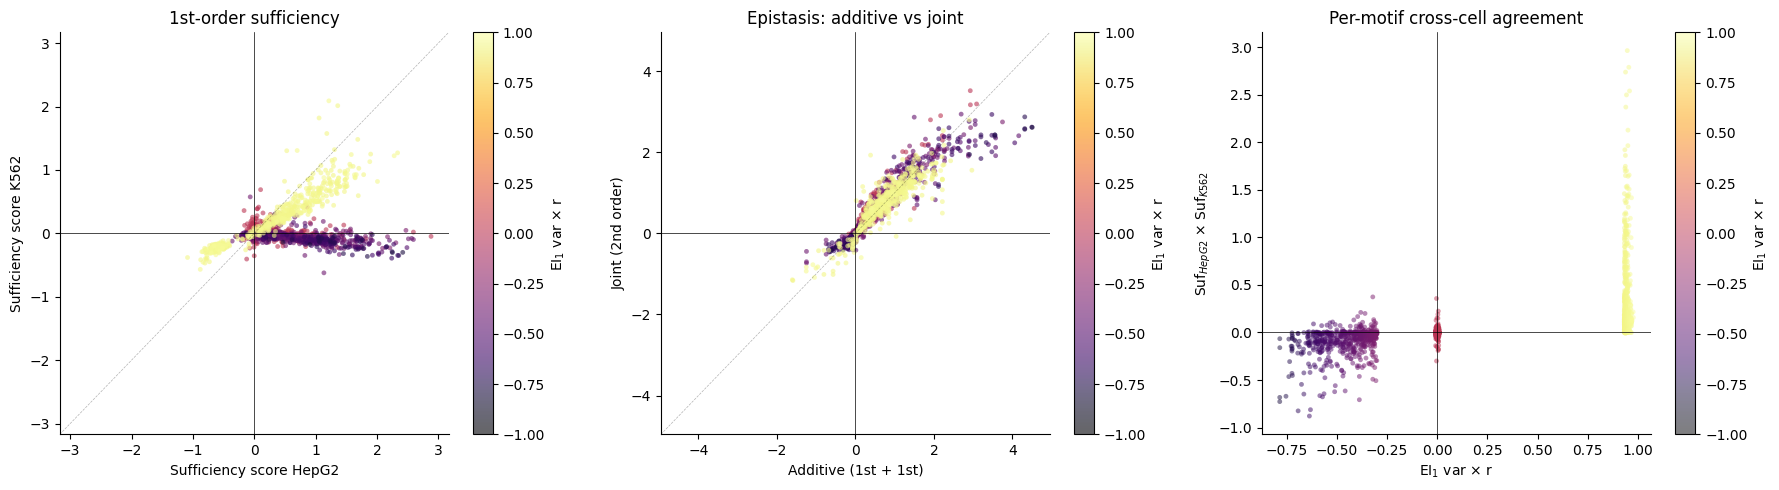

1647 1st-order sufficiency tests across 1059 sequences


In [28]:
# collect 1st-order sufficiency scores
suf_rows = []
for si, tests in enumerate(all_suf):
    for t in tests:
        if t['order'] == 1:
            suf_rows.append({
                'seq_idx': si,
                'tf': t['motifs'][0]['tf'],
                'start': t['motifs'][0]['start'],
                'end': t['motifs'][0]['end'],
                'suf_HepG2': t['scores']['HepG2'],
                'suf_K562': t['scores']['K562'],
                'EI_1_vxr': df.iloc[si]['EI_1 var x r'],
            })
suf_df = pd.DataFrame(suf_rows)
suf_df['agreement'] = suf_df['suf_HepG2'] * suf_df['suf_K562']

# collect 2nd-order sufficiency scores
suf2_rows = []
for si, tests in enumerate(all_suf):
    for t in tests:
        if t['order'] == 2:
            suf2_rows.append({
                'seq_idx': si,
                'suf2_HepG2': t['scores']['HepG2'],
                'suf2_K562': t['scores']['K562'],
            })
suf2_df = pd.DataFrame(suf2_rows) if suf2_rows else None

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) HepG2 vs K562 sufficiency scores colored by EI_1 var x r
order = np.argsort(np.abs(suf_df['EI_1_vxr'].values))
sc = axes[0].scatter(suf_df.suf_HepG2.values[order], suf_df.suf_K562.values[order],
                     s=12, alpha=0.6, c=suf_df['EI_1_vxr'].values[order],
                     cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
lim = np.abs(suf_df[['suf_HepG2','suf_K562']].values).max() * 1.1
axes[0].set_xlim(-lim, lim); axes[0].set_ylim(-lim, lim)
axes[0].axhline(0, c='k', lw=0.5); axes[0].axvline(0, c='k', lw=0.5)
axes[0].plot([-lim, lim], [-lim, lim], 'k--', lw=0.5, alpha=0.3)
axes[0].set_xlabel('Sufficiency score HepG2'); axes[0].set_ylabel('Sufficiency score K562')
plt.colorbar(sc, ax=axes[0], label='EI$_1$ var $\\times$ r')
axes[0].set_title('1st-order sufficiency')

# 2) 1st vs 2nd order: epistasis
if suf2_df is not None and len(suf2_df) > 0:
    epi_rows = []
    for si, tests in enumerate(all_suf):
        first = {t['motifs'][0]['tf']: t for t in tests if t['order'] == 1}
        for t in tests:
            if t['order'] == 2:
                tf1, tf2 = t['motifs'][0]['tf'], t['motifs'][1]['tf']
                if tf1 in first and tf2 in first:
                    for ct in ['HepG2', 'K562']:
                        additive = first[tf1]['scores'][ct] + first[tf2]['scores'][ct]
                        joint = t['scores'][ct]
                        epi_rows.append({'seq_idx': si, 'ct': ct,
                                         'additive': additive, 'joint': joint,
                                         'EI_1_vxr': df.iloc[si]['EI_1 var x r']})
    epi_df = pd.DataFrame(epi_rows)
    order_e = np.argsort(np.abs(epi_df['EI_1_vxr'].values))
    sc2 = axes[1].scatter(epi_df.additive.values[order_e], epi_df.joint.values[order_e],
                          s=12, alpha=0.6, c=epi_df['EI_1_vxr'].values[order_e],
                          cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
    elim = max(np.abs(epi_df[['additive','joint']].values).max() * 1.1, 0.1)
    axes[1].set_xlim(-elim, elim); axes[1].set_ylim(-elim, elim)
    axes[1].plot([-elim, elim], [-elim, elim], 'k--', lw=0.5, alpha=0.3)
    axes[1].axhline(0, c='k', lw=0.5); axes[1].axvline(0, c='k', lw=0.5)
    axes[1].set_xlabel('Additive (1st + 1st)'); axes[1].set_ylabel('Joint (2nd order)')
    plt.colorbar(sc2, ax=axes[1], label='EI$_1$ var $\\times$ r')
    axes[1].set_title('Epistasis: additive vs joint')

# 3) per-motif cross-cell agreement vs EI_1 var x r
order_a = np.argsort(np.abs(suf_df['EI_1_vxr'].values))
sc3 = axes[2].scatter(suf_df['EI_1_vxr'].values[order_a],
                      suf_df['agreement'].values[order_a],
                      s=12, alpha=0.5, c=suf_df['EI_1_vxr'].values[order_a],
                      cmap='inferno', vmin=-1, vmax=1, edgecolors='none')
axes[2].axhline(0, c='k', lw=0.5); axes[2].axvline(0, c='k', lw=0.5)
axes[2].set_xlabel('EI$_1$ var $\\times$ r')
axes[2].set_ylabel('Suf$_{HepG2}$ $\\times$ Suf$_{K562}$')
plt.colorbar(sc3, ax=axes[2], label='EI$_1$ var $\\times$ r')
axes[2].set_title('Per-motif cross-cell agreement')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'{len(suf_df)} 1st-order sufficiency tests across {suf_df.seq_idx.nunique()} sequences')

In [25]:
# save results
save_dir = os.path.join(REPO, 'virtual_perturbations', 'results')
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'necessity_results.pkl'), 'wb') as f:
    pickle.dump({'results': all_nec, 'n_rep': n_rep,
                 'nec_order': nec_order}, f)

with open(os.path.join(save_dir, 'sufficiency_results.pkl'), 'wb') as f:
    pickle.dump({'results': all_suf, 'n_rep': n_rep,
                 'suf_order': suf_order}, f)

print(f'Saved to {save_dir}')

Saved to /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/virtual_perturbations/results
